# Часть 1. Проверка гипотезы в Python и составление аналитической записки

Вы предобработали данные в SQL, и теперь они готовы для проверки гипотезы в Python. Загрузите данные пользователей из Москвы и Санкт-Петербурга c суммой часов их активности из файла yandex_knigi_data.csv. Если работаете локально, скачать файл можно по ссылке.

Проверьте наличие дубликатов в идентификаторах пользователей. Сравните размеры групп, их статистики и распределение.

Напомним, как выглядит гипотеза: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуйте статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

Нулевая гипотеза $H_0: \mu_{\text{СПб}} \leq \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге не больше, чем в Москве.

Альтернативная гипотеза $H_1: \mu_{\text{СПб}} > \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

По результатам анализа данных подготовьте аналитическую записку, в которой опишите:

Выбранный тип t-теста и уровень статистической значимости.

Результат теста, или p-value.

Вывод на основе полученного p-value, то есть интерпретацию результатов.

Одну или две возможные причины, объясняющие полученные результаты.

## Напишите заголовок первой части проекта здесь

- Автор: Козлова Екатерина
- Дата: 05.04.2026 - 06.04.2026

## Цели и задачи проекта

**Цель проекта** - проверить гипотезу о том, что пользователи из Санкт‑Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы, на основе данных об активности пользователей.

**Задачи проекта**:
- Загрузка данных, знакомство с ними и первичная проверка
- Предобработка данных
- Проверка статистических предположений (например, при помощи t-теста)
- Статистическая проверка гипотезы
- Интерпретация полученных результатов и подготовка аналитической записки

## Описание данных

Данные датасета knigi_data.csv содержат следующую информацию:

* city - город пользователя
* puid - идентификационный номер пользователя
* hours - сумма часов активности пользователей

## Содержимое проекта

* [Загрузка данных и знакомство с ними](#1bullet) 
* [Проверка гипотезы в Python](#2bullet)
* [Аналитическая записка](#3bullet)

## 1. Загрузка данных и знакомство с ними

Загрузите данные пользователей из Москвы и Санкт-Петербурга c их активностью (суммой часов чтения и прослушивания) из файла `/datasets/yandex_knigi_data.csv`.

In [2]:
# Загрузим необходимые библиотеки, которые будут использованы в настоящем проекте
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, mannwhitneyu

In [2]:
knigi= pd.read_csv('https://code.s3.yandex.net/datasets/yandex_knigi_data.csv')
knigi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  8784 non-null   int64  
 1   city        8784 non-null   object 
 2   puid        8784 non-null   int64  
 3   hours       8784 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 274.6+ KB


In [3]:
knigi.head()

,Unnamed: 0,city,puid,hours
0,0,Москва,9668,26.167776
1,1,Москва,16598,82.111217
2,2,Москва,80401,4.656906
3,3,Москва,140205,1.840556
4,4,Москва,248755,151.326434


На основе полученных данных мы видим, что датафрейм содержит 8784 записей. Пропусков нет ни в одном столбце, все они заполненны. Типы данных также представлены в корректных форматах.

In [4]:
knigi.duplicated().sum() # проверка явных дубликатов

0

In [5]:
num_duplicates = knigi.duplicated(subset=['puid']).sum() # проверка неявных дубликатов по столбцу с данными о пользователях

total_records = len(knigi)
duplicate_percentage = (num_duplicates / total_records) * 100

print(f"Общее количество записей: {total_records}")
print(f"Количество дубликатов puid: {num_duplicates}")
print(f"Процент дубликатов: {duplicate_percentage:.2f}%")

Общее количество записей: 8784
Количество дубликатов puid: 244
Процент дубликатов: 2.78%


Посколько дубликатов очень мало (примерно 3% от всего датасета) логичнее будет удалить их

In [6]:
knigi.drop_duplicates(subset=['puid'], keep=False, inplace=True)
knigi.drop(columns=['Unnamed: 0'], inplace = True) #удалим столбец который дублирует нумерацию
knigi.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8296 entries, 0 to 8783
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   city    8296 non-null   object 
 1   puid    8296 non-null   int64  
 2   hours   8296 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 259.2+ KB


После предварительной работы с данными мы удалили 244 дубликата, оставив в датафрейме 8296 уникальных значений.

## 2. Проверка гипотезы в Python

Гипотеза звучит так: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуйте статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

- Нулевая гипотеза H₀: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

- Альтернативная гипотеза H₁: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

In [7]:
knigi_msk = knigi[knigi['city'] == 'Москва']['hours']
knigi_spb = knigi[knigi['city'] == 'Санкт-Петербург']['hours']


print(f"Размер выборки Москва: {len(knigi_msk)}")
print(f"Размер выборки Санкт-Петербург: {len(knigi_spb)}")

stats_msk = knigi_msk.describe()
stats_spb = knigi_spb.describe()

comparison = pd.DataFrame({
    'Москва': stats_msk,
    'Санкт-Петербург': stats_spb
})
print("Описательные статистики:")
print(comparison)

# Средние значения
mean_msk = knigi_msk.mean()
mean_spb = knigi_spb.mean()
print(f"\nСреднее время активности:")
print(f"Москва: {mean_msk:.2f} часов")
print(f"Санкт-Петербург: {mean_spb:.2f} часов")

Размер выборки Москва: 5990
Размер выборки Санкт-Петербург: 2306
Описательные статистики:
            Москва  Санкт-Петербург
count  5990.000000      2306.000000
mean     10.848192        11.264433
std      36.925622        39.831755
min       0.000022         0.000025
25%       0.057042         0.060173
50%       0.888232         0.875355
75%       5.933439         6.138424
max     857.209373       978.764775

Среднее время активности:
Москва: 10.85 часов
Санкт-Петербург: 11.26 часов


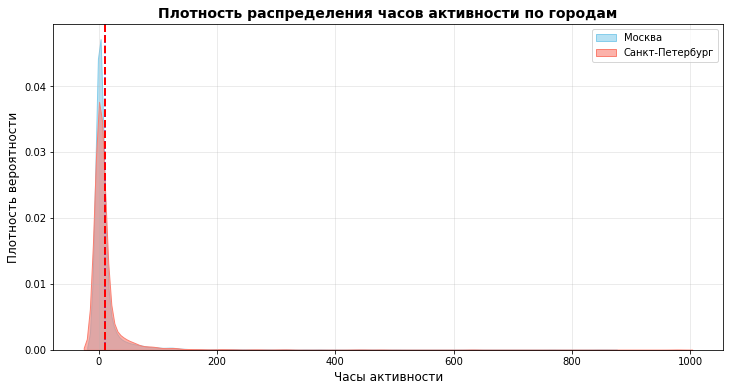

In [8]:
plt.figure(figsize=(12, 6))

sns.kdeplot(knigi_msk, label='Москва', fill=True, alpha=0.6, color='skyblue')
sns.kdeplot(knigi_spb, label='Санкт-Петербург', fill=True, alpha=0.6, color='salmon')

plt.axvline(knigi_msk.mean(), color='blue', linestyle='--', linewidth=2)
plt.axvline(knigi_spb.mean(), color='red', linestyle='--', linewidth=2)

plt.title('Плотность распределения часов активности по городам', fontsize=14, fontweight='bold')
plt.xlabel('Часы активности', fontsize=12)
plt.ylabel('Плотность вероятности', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Средняя активность: Санкт-Петербург (11.26 ч) немного выше, чем Москва (10.85 ч), но разница (0.41 ч) может не быть статистически значимой.
Дисперсия высокая (std: 36.93 для Москвы, 39.83 для СПб), много выбросов — распределение асимметрично, скошено влево.
Основная масса пользователей (до 75-го процентиля) в обоих городах показывает почти одинаковую активность (Q3: 5.93 ч для Москвы, 6.14 ч для СПб).
Размеры выборок неравны: Москва (5 990), Санкт-Петербург (2 306).
На основе данных самым оптимальным будет провести тест Манна–Уитни (из-за асимметрии).

In [9]:
stat, p_value = ttest_ind(
    knigi_msk,
    knigi_spb,
    equal_var=False,  
    alternative='less' 
)

alpha = 0.05

print(f't‑статистика: {stat:.4f}')
print(f'p‑значение: {p_value:.6f}')
print(f'Уровень значимости (alpha): {alpha}')

if p_value < alpha:
    print("Результат статистически значим (p < 0.05).")
    print("Среднее время в приложении в Москве статистически значимо больше, чем в Санкт‑Петербурге.")
else:
    print("Нет статистически значимых различий (p ≥ 0.05).")
    print("Нельзя утверждать, что среднее время в Москве больше, чем в Санкт‑Петербурге.")

t‑статистика: -0.4350
p‑значение: 0.331796
Уровень значимости (alpha): 0.05
Нет статистически значимых различий (p ≥ 0.05).
Нельзя утверждать, что среднее время в Москве больше, чем в Санкт‑Петербурге.


## 3. Аналитическая записка

Для проверки гипотезы о различиях в средней активности пользователей из Москвы и Санкт‑Петербурга был использован t‑тест Уэлча. Выбор этого теста обусловлен следующими факторами: неравномерные размеры выборок (Москва — 5 990 наблюдений, Санкт‑Петербург — 2 306 наблюдений); t‑тест Уэлча достаточно устойчив к отклонениям от нормальности при больших выборках; основная цель исследования - сравнить средние значения между группами. 

Результат теста:
* t‑статистика: −0,4350;
* p‑значение (p‑value): 0,331796;
* уровень значимости (α): 0,05.

Так как p‑значение (0,331796) больше уровня значимости (0,05), мы не отвергаем нулевую гипотезу (H₀). Это означает, что нет статистически значимых различий в среднем времени активности между пользователями из Москвы и Санкт‑Петербурга; наблюдаемая разница в средних значениях (10,85 ч для Москвы против 11,26 ч для Санкт‑Петербурга) является скорее всего случайной и не отражает реального различия в поведении пользователей.

Возможные причины полученных результатов:

- скорее всего жители Спб и Москвы схожи, т.к. оба города являются крупными мегаполисами, люди в них имеют схожий образ жизни, график и т.д.
- какие-то слишком высокие средние значения могут быть связаны с тем, что, например, какие-то пользователи более активны.